# Initial checks for VAE training and latent space inference



In [1]:
!git clone https://github.com/javiuv/GenNN-InverseMicro.git

Cloning into 'GenNN-InverseMicro'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 51 (delta 15), reused 43 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 9.13 KiB | 4.56 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [2]:
%cd GenNN-InverseMicro/
!git checkout feature/vae-prior

/content/GenNN-InverseMicro
Branch 'feature/vae-prior' set up to track remote branch 'feature/vae-prior' from 'origin'.
Switched to a new branch 'feature/vae-prior'


## MNIST dataset

In [3]:
import torch

In [4]:
from tensorflow.keras.datasets import mnist
(x_train, y_train_ds), (x_test, y_test_ds) = mnist.load_data()

def load_mnist(X,y,n,test_size=0.2):
    X_mnist = X[:n] / 255.0
    y_mnist = y[:n]

    X_mnist = X_mnist.reshape(-1, 1, 28, 28)

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X_mnist, y_mnist, test_size=test_size, stratify=y_mnist, random_state=0
    # )

    X_train = torch.tensor(X_mnist, dtype=torch.float32)
    # X_test = torch.tensor(X_test, dtype=torch.float32)

    return X_train, y

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## VAE training

In [5]:
def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

In [28]:
vae_code = """import torch
import torch.nn as nn


class VAE(nn.Module):
    def __init__(
        self,
        input_channels: int = 1,
        latent_dim: int = 2,
        hidden_dims=None,
        input_size: int = 28,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64]

        self.input_size = input_size
        self.hidden_dims = hidden_dims

        # -------------------
        # Encoder
        # -------------------
        modules = []
        in_channels = input_channels

        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU()
                )
            )
            in_channels = h_dim

        self.encoder = nn.Sequential(*modules)

        # Determine flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_size, input_size)
            enc_out = self.encoder(dummy)
            self.enc_shape = enc_out.shape[1:]
            self.flattened_size = enc_out.numel()

        # Latent space
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # -------------------
        # Decoder
        # -------------------
        self.fc_dec = nn.Linear(latent_dim, self.flattened_size)
        hidden_dims_rev = hidden_dims[::-1]

        modules = []
        for i in range(len(hidden_dims_rev) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        hidden_dims_rev[i],
                        hidden_dims_rev[i + 1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1
                    ),
                    nn.BatchNorm2d(hidden_dims_rev[i + 1]),
                    nn.LeakyReLU()
                )
            )

        # Last layer of decoder to output original input_channels
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    hidden_dims_rev[-1], # Corrected from hidden_dims[-1] to hidden_dims_rev[-1]
                    input_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1
                ),
                nn.Sigmoid()
            )
        )

        self.decoder = nn.Sequential(*modules)

    def encode(self, x):
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, *self.enc_shape)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

    def reconstruc(self, x):
        x_hat, _, _, _ = self.forward(x)
        return x_hat

    def sample(self, n_samples, device):
        z = torch.randn(n_samples, self.fc_mu.out_features).to(device)
        return self.decode(z)
"""

with open('/content/GenNN-InverseMicro/src/architecture/vae.py', 'w') as f:
    f.write(vae_code)

# Force reload of the module to pick up changes
import sys
if 'src.architecture.vae' in sys.modules:
    del sys.modules['src.architecture.vae']
if 'src.architecture' in sys.modules:
    del sys.modules['src.architecture']
if 'src' in sys.modules:
    del sys.modules['src']

from src.architecture.vae import VAE
from src.training import train_vae
import yaml
import tqdm
from torch.utils.data import DataLoader, TensorDataset

X_train, y_train = load_mnist(x_train, y_train_ds, 6000)

config = load_config("_config/vae_training.yaml")
model_params = config['model_params']
t_params = config['training_params']

# Fix Problem: Parse hidden_dims if it's a list containing a single string
if isinstance(model_params['hidden_dims'], list) and len(model_params['hidden_dims']) == 1 and isinstance(model_params['hidden_dims'][0], str):
    model_params['hidden_dims'] = [int(x) for x in model_params['hidden_dims'][0].split()]

device = torch.device(t_params['device'] if torch.cuda.is_available() else "cpu")
model = VAE(**model_params).to(device) # Instantiate VAE with model_params
optimizer = torch.optim.Adam(model.parameters(), lr=t_params['learning_rate'])

beta = t_params['beta']
num_epochs = t_params['epochs']
batch_size = t_params['batch_size']

if not isinstance(X_train, torch.Tensor):
    X_train = torch.tensor(X_train, dtype=torch.float32)

dataset = TensorDataset(X_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

for epoch in tqdm.tqdm(range(num_epochs)):
    train_vae(model, dataloader, optimizer, beta, device)

100%|██████████| 500/500 [01:16<00:00,  6.55it/s]


In [13]:
def plot_reconstructions_convvae(model, X, n=10):
    device = next(model.parameters()).device
    idx = np.random.choice(len(X), n, replace=False)
    originals = X[idx].detach().cpu().numpy() # Keep the (batch_size, 1, 8, 8) shape

    # If model is ConvVAE, forward pass might return (x_hat, mu, logvar)
    if isinstance(model, VAE):
        x_hat, _, _ = model(X[idx].to(device))
    else:
        x_hat = model(X[idx].to(device))

    recons = x_hat.cpu().detach().numpy() # Keep the (batch_size, 1, 8, 8) shape

    plt.figure(figsize=(10, 3))
    for i in range(n):
        # original: reshape from (1, 8, 8) to (8, 8)
        plt.subplot(2, n, i+1)
        plt.imshow(originals[i].reshape(28,28), cmap='gray')
        plt.axis('off')

        # reconstruction: reshape from (1, 8, 8) to (8, 8)
        plt.subplot(2, n, n + i + 1)
        plt.imshow(recons[i].reshape(28,28), cmap='gray')
        plt.axis('off')

    plt.suptitle("Original (top) vs Reconstruction (bottom)")
    plt.show()

def plot_latent_convvae(model, X, y):
    device = next(model.parameters()).device
    with torch.no_grad():
        mu, logvar = model.encode(X.to(device))
        z = model.reparameterize(mu, logvar).cpu()

    plt.figure(figsize=(6,5))
    scatter = plt.scatter(z[:,0], z[:,1], c=y/9, cmap='tab10', s=10)
    plt.colorbar(scatter)
    plt.title("Latent space colored by digit label")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.show()

def generate_synthetic_digits_convvae(model, X_train, n_samples=20, components=10):
    # get latent codes
    device = next(model.parameters()).device
    X_train = X_train.to(device)
    with torch.no_grad():
        # Assuming X_train is already 4D here (n_samples, 1, 8, 8)
        mu, logvar = model.encode(X_train)
        Z = model.reparameterize(mu, logvar).cpu().numpy()

    # Fit a GMM
    gmm = GaussianMixture(n_components=components)
    gmm.fit(Z)

    # sample latent points, decode
    z_synth = gmm.sample(n_samples)[0]
    z_synth_torch = torch.tensor(z_synth, dtype=torch.float32).to(device)

    X_generated = model.decode(z_synth_torch).cpu().detach().numpy()

    # plot generated digits: reshape from (1, 8, 8) to (8, 8)
    plt.figure(figsize=(10,2))
    for i in range(n_samples):
        plt.subplot(1, n_samples, i+1)
        plt.imshow(X_generated[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    plt.suptitle("Synthetic digits from GMM sampling")
    plt.show()

    return X_generated



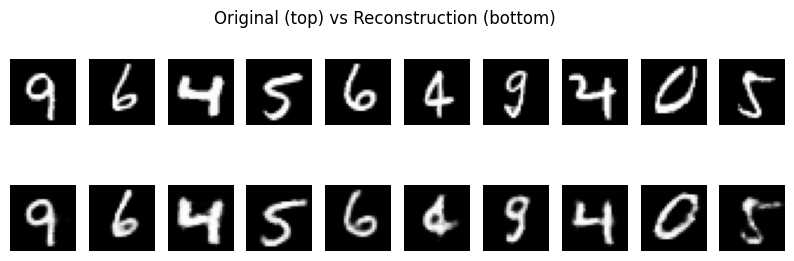

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

X_test = torch.tensor(x_test/255.0, dtype=torch.float32).reshape(-1, 1, 28, 28)

plot_reconstructions_convvae(model, X_test, n=10)

## Inference

In [40]:
from src.reconstruction.vae_latent import VAELatentReconstructor
from src.operators import get_forward_operator

with open("_config/distortion_operator.yaml", 'r') as f:
    operator_cfg = yaml.safe_load(f)

# if method == 'vae': only VAE for now
with open("_config/vae_training.yaml", 'r') as f:
    model_cfg = yaml.safe_load(f)

with open("_config/vae_inference.yaml", 'r') as f:
    recon_cfg = yaml.safe_load(f)

device = torch.device(model_cfg['training_params']['device'] if torch.cuda.is_available() else "cpu")

distorsion_operator = get_forward_operator(operator_cfg)

# model = VAE(**model_cfg['model_params']).to(device)
# model.load_state_dict(torch.load("models/vae/best_vae.pth", map_location=torch.device('cpu')))
# model.eval()

solver = VAELatentReconstructor(model, distorsion_operator)

z, img_recon = solver.reconstruct(X_test[0].unsqueeze(0).to(device), **recon_cfg)

100%|██████████| 1000/1000 [00:02<00:00, 383.19it/s]


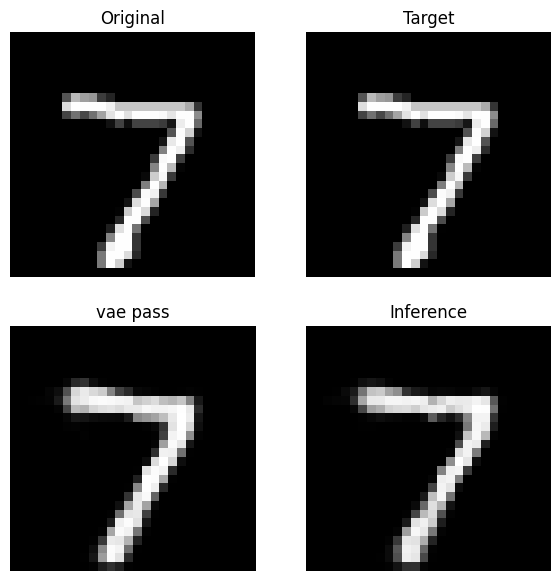

In [43]:
plt.figure(figsize=(7,7))

y_real = X_test[0]
y_target = X_test[0]
y_sol = img_recon

# original: reshape from (1, 8, 8) to (8, 8)
ax = plt.subplot(2, 2, 1)
ax.imshow(y_real.cpu().reshape(28,28), cmap='gray')
ax.set_title("Original")
ax.axis('off')

ax = plt.subplot(2, 2, 2)
ax.imshow(y_target.cpu().detach().numpy().reshape(28,28), cmap='gray')
ax.set_title("Target")
ax.axis('off')

# reconstruction: reshape from (1, 8, 8) to (8, 8)
ax = plt.subplot(2, 2, 4)
ax.imshow(y_sol.cpu().reshape(28,28), cmap='gray')
ax.set_title("Inference")
ax.axis('off')

ax =plt.subplot(2, 2, 3)
x_pass, _, _ = model(y_target.unsqueeze(0).to(device))
ax.imshow(x_pass.cpu().detach().numpy().reshape(28,28), cmap='gray')
ax.set_title("vae pass")
ax.axis('off')

plt.show()

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
torch.save(model.state_dict(), '/content/drive/MyDrive/vae_ini.pth')